# Computational Methods TP3

In [2]:
from lib_installer import check_and_install_libraries

check_and_install_libraries()

Checking libraries...

numpy is installed
matplotlib is installed
pandas is installed

All libraries ready


## Section 3: Base Case Results

The goal of Part 3 is to check that our dynamic programming model works properly by reproducing the base-case results from Section 4.1 of Das et al. (2020). In this section, we compute the in-sample probability of reaching the target wealth, plot the value function, and examine the optimal portfolio choices across time and wealth levels. We then run Monte Carlo simulations using the optimal policy to make sure that the simulated success rate matches the value produced by the dynamic program. By comparing our results with the ones reported in the paper, we can confirm that our implementation is accurate before moving on to the sensitivity analysis in Part 4.

The following section runs the base case analysis from Section 3 by calling the main wrapper function. It handles the full pipeline: constructing efficient portfolios, generating the shifted wealth grid for G = 200, computing transition probabilities and solving the model via backward induction (in sample validation), and finally running the Monte Carlo simulation for forward testing (Out of sample testing).

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from main import run_base_case

w0, G, T, w_grid, V, policy, W_paths, p_in, p_oos = run_base_case()

# Print the key results to verify against the Das et al. paper
# The paper reports 0.669. Our improved grid should yield approx 0.670.
print(f"In-sample success probability  : {p_in:.4f}")
print(f"Out-of-sample success probability: {p_oos:.4f}")

------ Base Case Results ------
In-sample success probability  : 0.6703
Out-of-sample success probability: 0.6698
--------------------------------
In-sample success probability  : 0.6703
Out-of-sample success probability: 0.6698


### Section 3.1) Value function evolution at 3 different times 

The goal of Section 3.1 is to compute and visualize the value function $V_t(W)$ at different points in time in order to confirm that the dynamic programming model is behaving correctly. The value function represents the maximum probability of reaching the goal wealth by the final horizon, given the current wealth and the remaining time. 

By plotting $V_t(W)$ at the start of the horizon, halfway through, and at maturity, we can check that the shape of the value function matches the behavior described in Section 4.1 of Das et al. (2020). In particular, the value function should approach a step function at the terminal date, while earlier curves should show a smooth transition from low to high success probabilities as wealth increases.

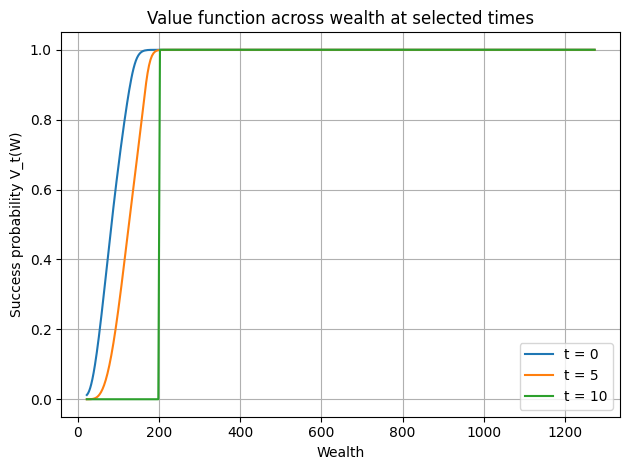

In [ ]:
import os
import matplotlib.pyplot as plt

# Ensure output directory exists
os.makedirs("plots", exist_ok=True)

# This plot illustrates how the probability of success V_t(W) changes 
# as a function of wealth at different points in time.
plt.figure()

# Select representative times to show the progression:
# t=0 (Start), t=5 (Midpoint), t=10 (Maturity)
times = [0, T // 2, T]

for t in times:
    # Plot the value function for time t across the entire wealth grid
    plt.plot(w_grid, V[t, :], label=f"t = {t}")

# Formatting
plt.xlabel("Wealth")
plt.ylabel("Success probability V_t(W)")
plt.title("Value function across wealth at selected times")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save to file for LaTeX
plt.savefig("plots/value_function_plot.png", dpi=300)

plt.show()


### Section 3.2) Optimal policy heatmap 

The goal of this section is to visualize the optimal portfolio policy produced by the dynamic programming algorithm, showing how the chosen portfolio index varies with both time and current wealth. In the model, each portfolio on the efficient frontier corresponds to a different risk–return tradeoff, so the heatmap helps us understand how the optimal strategy adjusts risk over the investment horizon. 

Reproducing the behavior described in Section 4.1 of Das et al. (2020), we expect the policy to select very aggressive portfolios when wealth is far below the goal, since high expected returns are needed to have any chance of catching up. As wealth approaches or exceeds the target, the optimal choice should switch sharply toward more conservative portfolios to avoid unnecessary volatility and reduce the chance of falling back below the goal.


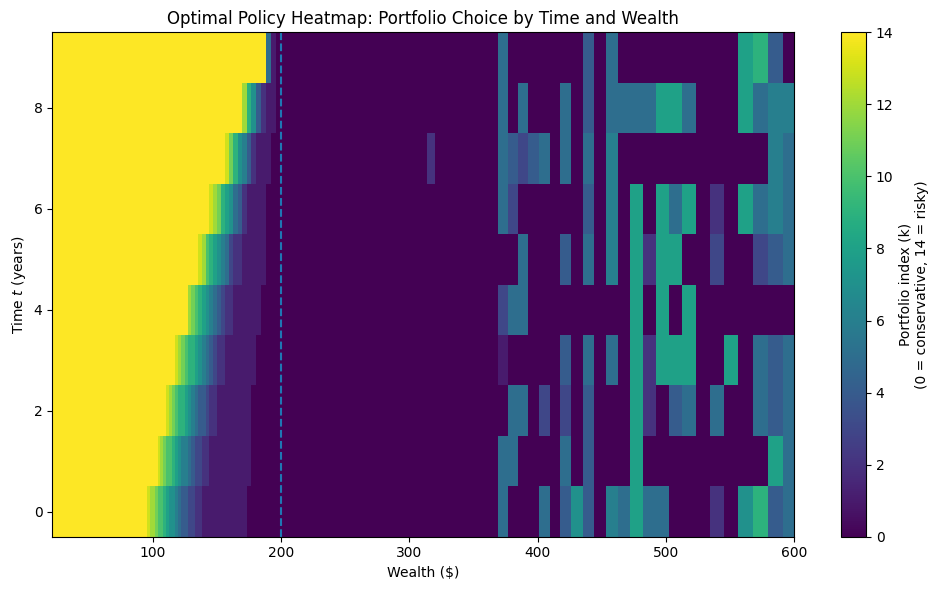

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Ensure output directory exists
os.makedirs("plots", exist_ok=True)

# Prepare the Grid for Plotting
# We use meshgrid because w_grid is logarithmically spaced.
time_steps = np.arange(T)  # 0..9
W_mesh, T_mesh = np.meshgrid(w_grid, time_steps)

plt.figure(figsize=(10, 6))

# Generate the Heatmap
# 'viridis' maps low values (0/conservative) to purple and high values (14/risky) to yellow.
c = plt.pcolormesh(
    W_mesh,
    T_mesh,
    policy,
    cmap="viridis",
    shading="auto"
)

# Visual Reference for the Goal
# The dashed line at G=200 shows where the "switch" to safety should happen.
plt.colorbar(c, label="Portfolio index (k)\n(0 = conservative, 14 = risky)")
plt.xlabel("Wealth ($)")
plt.ylabel("Time $t$ (years)")
plt.title("Optimal Policy Heatmap: Portfolio Choice by Time and Wealth")
plt.axvline(G, linestyle="--")
plt.xlim(w_grid[0], 600)

plt.tight_layout()

# Save to file for LaTeX
plt.savefig("plots/policy_heatmap.png", dpi=300)

plt.show()


### Section 3.3) Distribution of Terminal Wealth under the optimal policy 

In this section, we analyze the distribution of terminal wealth generated by the optimal policy and compare the simulated results with the in-sample success probability computed by the dynamic program. 

By simulating many wealth paths under the optimal strategy, we can observe the full range of outcomes: both the left-tail scenarios where repeated risk-taking does not pay off and the upper-tail cases where high returns accumulate over time. This section reproduces the behavior highlighted in Section 4.1 of Das et al. (2020), showing that the distribution is wide and asymmetric, with a meaningful probability of low outcomes but a median final wealth slightly above the goal. 

The simulation also allows us to compute an out-of-sample estimate of the probability of reaching the goal and verify that it closely matches the dynamic programming value. Indeed, this serves as an important consistency check, confirming that the grid discretization and transition probabilities are accurate and that the optimal policy performs as expected outside the dynamic programming framework.

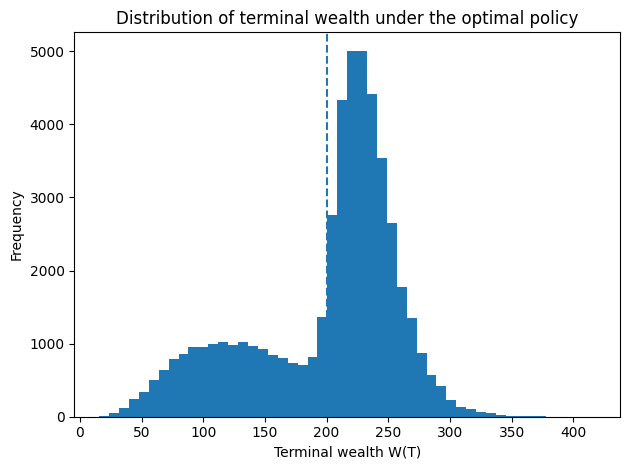

Quantiles of W(T):
10%: 100.23
25%: 162.73
50%: 218.79
75%: 239.57
90%: 259.58
Fraction of paths above G = 200.0: 0.6698


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Ensure the output directory exists for saving report figures
os.makedirs("plots", exist_ok=True)

# Extract Terminal Wealth
# W_paths has shape (n_paths, T+1). We take the last column (time T).
W_T = W_paths[:, -1]

# Generate Histogram (Figure 3 in Report)
plt.figure()
plt.hist(W_T, bins=50)
plt.axvline(G, linestyle="--")  # goal line
plt.xlabel("Terminal wealth W(T)")
plt.ylabel("Frequency")
plt.title("Distribution of terminal wealth under the optimal policy")
plt.tight_layout()

# Save to file for LaTeX
plt.savefig("plots/terminal_wealth_hist.png", dpi=300)

plt.show()

# Calculate Summary Statistics
q = np.quantile(W_T, [0.10, 0.25, 0.50, 0.75, 0.90])
print("Quantiles of W(T):")
for level, value in zip([0.10, 0.25, 0.50, 0.75, 0.90], q):
    print(f"{level:.0%}: {value:.2f}")

# Calculate Out-of-Sample Success Probability
# This number validates the In-Sample DP result (robustness check)
print(f"Fraction of paths above G = {G}: {(W_T >= G).mean():.4f}")


We also are able to create a heatmap of the value function $V_t(W)$ over time, but only for the range of wealth levels where the value function actually changes. This replicates the presentation in the paper, which restricts the plot to a meaningful wealth interval instead of displaying the entire grid.


The heatmap shows how the probability of reaching the goal, $V_t(W)$, evolves both with time $t$ (on the x-axis) and wealth $W$ (on the y-axis). Colors indicate the success probability, from near 0 (dark) to near 1 (bright). By focusing on a smaller wealth range, the plot highlights the transition region where the value function shifts from low to high probabilities, making the visualization clearer and more comparable to the figure in the paper.


Shapes: V = (11, 200) w_flat = (200,)
Sub-shapes: V_sub = (11, 88) w_sub = (88,)


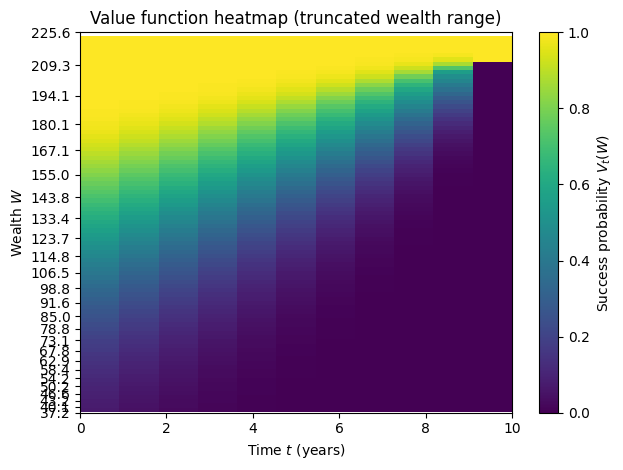

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

V = np.array(V)
w_flat = np.array(w_grid).reshape(-1)   

print("Shapes:", "V =", V.shape, "w_flat =", w_flat.shape)

# Select the wealth range [37, 226] like in the paper of Das et al.
w_min_disp = 37.0
w_max_disp = 226.0

mask = (w_flat >= w_min_disp) & (w_flat <= w_max_disp)
idx = np.where(mask)[0]             

w_sub = w_flat[idx]                     
V_sub = V[:, idx]                      

print("Sub-shapes:", "V_sub =", V_sub.shape, "w_sub =", w_sub.shape)

# Build the heatmap: x = time, y = wealth, color = V_t(W)
plt.figure()

plt.imshow(
    V_sub.T,
    aspect="auto",
    origin="lower",
    extent=[0, T, w_sub[0], w_sub[-1]]
)

cbar = plt.colorbar()
cbar.set_label("Success probability $V_t(W)$")

plt.xlabel("Time $t$ (years)")
plt.ylabel("Wealth $W$")

plt.title("Value function heatmap (truncated wealth range)")

# mimic the paper's y-ticks
yticks = [37.2, 40.1, 43.2, 46.6, 50.2, 54.2, 58.4, 62.9, 67.8,
          73.1, 78.8, 85.0, 91.6, 98.8, 106.5, 114.8, 123.7,
          133.4, 143.8, 155.0, 167.1, 180.1, 194.1, 209.3, 225.6]
plt.yticks(yticks)

plt.tight_layout()
plt.show()


## Section 4: Numerical Experiments and Sensitivity Analysis

The goal of Section 4 is to study how sensitive our dynamic programming results are to the choices we make when building the wealth grid. In particular, we look at two key parameters: the number of grid points $n_w$ and the range parameter $n_s$, which determines how wide the wealth grid is. 

By recomputing the in-sample and out-of-sample success probabilities for different values of these parameters, we can see how the accuracy and stability of the solution change. This section basically checks whether our base-case setup (used in Section 3) is reliable, and whether a too-coarse or too-narrow grid leads to biased or misleading results. Put differently, we would like to confirm that our model behaves consistently once the grid is chosen wide and dense enough.


In [9]:
import numpy as np
import pandas as pd

from build_portfolios import build_portfolios
from experiments import experiment_vary_nw, experiment_vary_ns


### Section 4.1) Effect of the grid range parameter $n_w$

The first experiment is to test how sensitive our results are to the number of wealth grid points $n_w$. Since the grid is used to approximate the continuous wealth space, choosing too few points can introduce interpolation errors, while using more points should give a more accurate representation of the wealth dynamics. 

In this section, we rerun the base-case experiment for different values of $n_w$ and compare the in-sample and out-of-sample success probabilities, along with the computation time. This helps us see whether the solution becomes more stable as the grid becomes finer, and it also validates the Das et al. paper’s claim that a coarse grid can lead to discrepancies between the DP estimate and the MC simulated probability of reaching the goal.


In [ ]:
# Experiment 1: Sensitivity to Grid Density (nw) 
# We test how the resolution of the grid affects the precision of the solution.
# Low nw (coarse grid) = faster but higher interpolation error.
# High nw (fine grid) = slower but better convergence between In-Sample and OOS.

# Build the 15 efficient portfolios once
vmu, vsi, weights, index_means, cov_matrix = build_portfolios()

# Use a fixed RNG so results are comparable across experiments
rng = np.random.default_rng(123)

nw_list = [50, 100, 200, 400]
ns = 3       # Keep the range fixed at the Base Case level
n_paths_oos = 20000  # fewer than 50k to keep runtime reasonable

# Run the experiment
results_nw = experiment_vary_nw(
    vmu, vsi,
    nw_list=nw_list,
    ns=ns,
    n_paths_oos=n_paths_oos,
    rng=rng
)

# Build a DataFrame to display the results (Table 1)
rows = []
for res in results_nw:
    rows.append({
        "nw": res["nw"],
        "p_in": res["p_success_in_sample"],
        "p_oos": res["p_success_oos"],
        "abs_diff": abs(res["p_success_in_sample"] - res["p_success_oos"]),
        "dp_time_sec": res["dp_time_sec"],
        "sim_time_sec": res["sim_time_sec"],
    })

df_nw = pd.DataFrame(rows)
df_nw


,nw,p_in,p_oos,abs_diff,dp_time_sec,sim_time_sec
0,50,0.670819,0.66345,0.007369,0.023783,0.018901
1,100,0.671454,0.67625,0.004796,0.022006,0.017362
2,200,0.670340,0.67210,0.001760,0.048246,0.019145
3,400,0.670127,0.67210,0.001973,0.142651,0.026528


### Effect of the grid range parameter $n_s$

The second experiment is to examine how the width of the wealth grid affects the accuracy of the dynamic programming results. Here we focus on the range parameter $n_s$, which controls how far the grid extends in terms of standard deviations of possible wealth outcomes. 

If this range is too narrow, the grid fails to include extreme but still realistic wealth values, which can distort the value function and make the in-sample probability look too optimistic. By testing several values of $n_s$, we can see how much coverage is needed to avoid truncation bias and to make sure that the DP results line up with the out-of-sample simulations. 

In [ ]:
# Experiment 2: Sensitivity to Grid Range (ns) 
# We test how the width of the grid affects the accuracy of the solution.
# Low ns (e.g., 1) cuts off tails; High ns (e.g., 4) captures extreme events but might waste grid points.

ns_list = [1, 2, 3, 4]
nw = 200
n_paths_oos = 20000

# Run the experiment (looping over ns_list)
results_ns = experiment_vary_ns(
    vmu, vsi,
    ns_list=ns_list,
    w0=100.0, G=200.0, T=10,
    nw=nw,
    n_paths_oos=n_paths_oos,
    rng=rng
)

# Process results into a structured format for the report table
rows = []
for res in results_ns:
    rows.append({
        "ns": res["ns"],
        "p_in": res["p_success_in_sample"],
        "p_oos": res["p_success_oos"],
        "abs_diff": abs(res["p_success_in_sample"] - res["p_success_oos"]),
        "dp_time_sec": res["dp_time_sec"],
        "sim_time_sec": res["sim_time_sec"],
    })

# Create DataFrame to display Table 2
df_ns = pd.DataFrame(rows)
df_ns


,ns,p_in,p_oos,abs_diff,dp_time_sec,sim_time_sec
0,1,0.722389,0.66440,0.057989,0.077489,0.029287
1,2,0.670338,0.67315,0.002812,0.052978,0.016109
2,3,0.670340,0.67645,0.006110,0.046536,0.020754
3,4,0.670529,0.67225,0.001721,0.059168,0.024132
